# Circuit-Level Performance On Half-Null-Row Errors

This notebook keeps the continuity of the older ?half-stabilizer performance? experiments, but the actual rows now come from the projected fault-model export:

- `Hz`: projected DEM check matrix used by the decoder
- `Lz`: projected DEM logical-observable matrix used by the decoder
- `Hx`: **heuristic low-weight independent nulls** in `ker([Hz; Lz])`

Important considerations:

1. These `Hx` rows are **not data-block stabilizers**.
   They are low-weight null fault combinations in the projected Z sector.

2. The export notebook already enforces a low-weight cap and an independence cap.
   That means this performance notebook can enumerate all half-subsets of all exported rows without exploding combinatorially.

3. This experiment is meaningful only relative to the **chosen heuristic low-weight-null family**.
   It is not a basis-invariant statement about the full nullspace.

In [1]:
import json
from itertools import combinations
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import relay_bp

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=140, suppress=True)

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "testdata").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}.")


repo_root = find_repo_root(Path.cwd().resolve())
export_dir = repo_root / "examples" / "notebook_data" / "stim_decoder_npz_exports"

CODE_PATHS = {
    "gross": export_dir / "gross_from_stim_Z_basis_fault_projection.npz",
    "two_gross": export_dir / "two_gross_from_stim_Z_basis_fault_projection.npz",
    "surface": export_dir / "surface13_from_stim_Z_basis_fault_projection.npz",
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.10
max_iter = 40
alpha = 1.0
same_memory_coefficient = 0.15
random_positive_range = (0.0, 0.30)
random_signed_range = (-0.30, 0.30)
memory_application_scope = "null_support"  # options: "null_support", "all_bits"
base_disorder_seed = 0
random_coefficient_seed_offsets = [0, 1, 2]

DECODER_SPECS = {
    "bp": {"label": "Vanilla BP", "coeff_seed_offsets": [0]},
    "mem_same": {"label": "Mem-BP / same coefficient", "coeff_seed_offsets": [0]},
    "mem_positive_random": {"label": "Mem-BP / random positive disorder", "coeff_seed_offsets": random_coefficient_seed_offsets},
    "mem_signed_random": {"label": "Mem-BP / random signed disorder", "coeff_seed_offsets": random_coefficient_seed_offsets},
}

In [3]:
def load_projected_fault_code(path: Path) -> dict[str, object]:
    data = np.load(path, allow_pickle=True)
    hx = np.asarray(data["Hx"], dtype=np.uint8) % 2
    hz = np.asarray(data["Hz"], dtype=np.uint8) % 2
    lz = np.asarray(data["Lz"], dtype=np.uint8) % 2
    metadata = json.loads(str(np.asarray(data["metadata_json"]).item()))
    if metadata.get("Hx_semantics") != "heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz]":
        raise ValueError("This notebook expects the new low-weight-null export format. Rerun ExportStimDecoderMatricesToCodeCapacityNpzs.ipynb first.")
    return {"Hx": hx, "Hz": hz, "Lz": lz, "metadata": metadata}


def null_row_statistics(hx: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = hx.sum(axis=1).astype(int)
    unique_weights, counts = np.unique(weights, return_counts=True)
    rows = []
    total_raw_half_subsets = 0
    total_even_rows = 0
    for weight, count in zip(unique_weights, counts):
        weight = int(weight)
        count = int(count)
        is_even = weight > 0 and weight % 2 == 0
        raw_half_subsets_per_row = comb(weight, weight // 2) if is_even else 0
        total_raw = count * raw_half_subsets_per_row
        if is_even:
            total_raw_half_subsets += total_raw
            total_even_rows += count
        rows.append({
            "row_weight": weight,
            "n_null_rows": count,
            "is_even_weight": is_even,
            "raw_half_subsets_per_row": raw_half_subsets_per_row,
            "total_raw_half_subsets": total_raw,
        })
    summary = pd.DataFrame([{
        "code": selected_code,
        "Hx_rows": int(hx.shape[0]),
        "n_fault_mechanisms": int(hx.shape[1]),
        "even_null_rows": total_even_rows,
        "total_half_flip_patterns": int(total_raw_half_subsets),
    }])
    return pd.DataFrame(rows), summary


def all_half_subsets(support_faults: tuple[int, ...]) -> list[tuple[int, ...]]:
    support_faults = tuple(sorted(int(bit) for bit in support_faults))
    if len(support_faults) == 0 or len(support_faults) % 2 != 0:
        return []
    half_weight = len(support_faults) // 2
    return [tuple(sorted(subset)) for subset in combinations(support_faults, half_weight)]


def enumerate_half_null_cases(hx: np.ndarray, hz: np.ndarray, lz: np.ndarray) -> list[dict[str, object]]:
    cases = []
    case_id = 0
    for row_idx in range(hx.shape[0]):
        support_faults = np.flatnonzero(hx[row_idx]).astype(int).tolist()
        if len(support_faults) == 0 or len(support_faults) % 2 != 0:
            continue
        for half_subset_idx, flipped_faults in enumerate(all_half_subsets(tuple(support_faults))):
            error = np.zeros(hz.shape[1], dtype=np.uint8)
            error[list(flipped_faults)] = 1
            syndrome = np.asarray((hz @ error) % 2, dtype=np.uint8).reshape(-1)
            logical_signature = np.asarray((lz @ error) % 2, dtype=np.uint8).reshape(-1)
            cases.append({
                "case_id": case_id,
                "row_idx": row_idx,
                "row_weight": len(support_faults),
                "half_subset_idx": half_subset_idx,
                "support_faults": tuple(support_faults),
                "flipped_faults": tuple(int(bit) for bit in flipped_faults),
                "error": error,
                "syndrome": syndrome,
                "logical_signature": logical_signature,
                "syndrome_weight": int(syndrome.sum()),
                "logical_weight": int(logical_signature.sum()),
            })
            case_id += 1
    return cases


def get_memory_target_indices(n_bits: int, support_faults: tuple[int, ...]) -> np.ndarray:
    if memory_application_scope == "null_support":
        return np.asarray(support_faults, dtype=int)
    if memory_application_scope == "all_bits":
        return np.arange(n_bits, dtype=int)
    raise ValueError(f"Unsupported memory_application_scope: {memory_application_scope}")


def build_memory_strengths(decoder_kind: str, n_bits: int, support_faults: tuple[int, ...], coeff_seed: int) -> np.ndarray | None:
    if decoder_kind == "bp":
        return None
    target_indices = get_memory_target_indices(n_bits, support_faults)
    strengths = np.zeros(n_bits, dtype=np.float64)
    if decoder_kind == "mem_same":
        strengths[target_indices] = same_memory_coefficient
        return strengths
    rng = np.random.default_rng(coeff_seed)
    if decoder_kind == "mem_positive_random":
        strengths[target_indices] = rng.uniform(random_positive_range[0], random_positive_range[1], size=target_indices.size)
        return strengths
    if decoder_kind == "mem_signed_random":
        strengths[target_indices] = rng.uniform(random_signed_range[0], random_signed_range[1], size=target_indices.size)
        return strengths
    raise ValueError(f"Unsupported decoder kind: {decoder_kind}")


def make_tracer(decoder_kind: str, check_matrix, error_priors: np.ndarray):
    gamma0 = None if decoder_kind == "bp" else 0.0
    return relay_bp.MinSumBPDecoderTraceF64(check_matrix, error_priors=error_priors, max_iter=max_iter, alpha=alpha, gamma0=gamma0)


def decode_case_with_tracer(tracer, syndrome: np.ndarray, memory_strengths: np.ndarray | None):
    tracer.reset()
    if memory_strengths is not None:
        tracer.set_memory_strengths(memory_strengths)
    result = tracer.snapshot(syndrome)
    while tracer.current_iteration < max_iter and not result.success:
        result = tracer.run_iteration(syndrome)
    return result


def evaluate_decoder(decoder_kind: str, cases: list[dict[str, object]], check_matrix, lz: np.ndarray) -> pd.DataFrame:
    spec = DECODER_SPECS[decoder_kind]
    error_priors = np.full(check_matrix.shape[1], prior_error_rate, dtype=np.float64)
    tracer = make_tracer(decoder_kind, check_matrix, error_priors)
    rows = []
    for case in cases:
        for coeff_seed_offset in spec["coeff_seed_offsets"]:
            coeff_seed = base_disorder_seed + (10_000 * coeff_seed_offset) + int(case["case_id"])
            memory_strengths = build_memory_strengths(decoder_kind, check_matrix.shape[1], case["support_faults"], coeff_seed)
            result = decode_case_with_tracer(tracer, case["syndrome"], memory_strengths)
            decoding = np.asarray(result.decoding, dtype=np.uint8)
            residual = np.bitwise_xor(decoding, case["error"])
            logical_signature = np.asarray((lz @ residual) % 2, dtype=np.uint8).reshape(-1)
            logical_success = bool(np.all(logical_signature == 0))
            exact_recovery = bool(np.array_equal(decoding, case["error"]))
            rows.append({
                "decoder_kind": decoder_kind,
                "decoder_label": spec["label"],
                "case_id": int(case["case_id"]),
                "row_idx": int(case["row_idx"]),
                "row_weight": int(case["row_weight"]),
                "half_subset_idx": int(case["half_subset_idx"]),
                "support_faults": list(case["support_faults"]),
                "flipped_faults": list(case["flipped_faults"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "logical_weight": int(case["logical_weight"]),
                "coeff_seed_offset": int(coeff_seed_offset),
                "coeff_seed": int(coeff_seed),
                "converged": bool(result.success),
                "logical_success": logical_success,
                "exact_recovery": exact_recovery,
                "iterations": int(result.iterations),
            })
    return pd.DataFrame(rows)


def summarize_results(results_df: pd.DataFrame, n_unique_cases: int) -> pd.DataFrame:
    converged_mask = results_df["converged"].to_numpy(dtype=bool)
    return pd.DataFrame([{
        "decoder": results_df["decoder_label"].iloc[0],
        "half_flip_patterns": n_unique_cases,
        "coefficient_repeats": int(results_df["coeff_seed_offset"].nunique()),
        "evaluations": int(len(results_df)),
        "convergence_rate": float(results_df["converged"].mean()),
        "logical_success_rate": float(results_df["logical_success"].mean()),
        "exact_recovery_rate": float(results_df["exact_recovery"].mean()),
        "logical_success_given_converged": float(results_df.loc[results_df["converged"], "logical_success"].mean()) if converged_mask.any() else np.nan,
        "mean_iterations": float(results_df["iterations"].mean()),
        "max_iterations_reached_rate": float((results_df["iterations"] >= max_iter).mean()),
    }])


def summarize_by_row_weight(results_df: pd.DataFrame) -> pd.DataFrame:
    grouped = (results_df.groupby("row_weight", as_index=False).agg(evaluations=("case_id", "size"), half_flip_patterns=("case_id", "nunique"), convergence_rate=("converged", "mean"), logical_success_rate=("logical_success", "mean"), exact_recovery_rate=("exact_recovery", "mean"), mean_iterations=("iterations", "mean")).sort_values("row_weight").reset_index(drop=True))
    return grouped


def category_table(results_df: pd.DataFrame) -> pd.DataFrame:
    labels = []
    for converged, logical_success in zip(results_df["converged"], results_df["logical_success"]):
        if converged and logical_success:
            labels.append("converged / logical success")
        elif converged and not logical_success:
            labels.append("converged / logical fail")
        elif (not converged) and logical_success:
            labels.append("not converged / logical success")
        else:
            labels.append("not converged / logical fail")
    counts = pd.Series(labels).value_counts().rename_axis("category").reset_index(name="count")
    counts["rate"] = counts["count"] / len(results_df)
    return counts


def plot_decoder_results(results_df: pd.DataFrame):
    grouped = summarize_by_row_weight(results_df)
    categories = category_table(results_df)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    x = np.arange(len(grouped))
    width = 0.24
    axes[0].bar(x - width, grouped["convergence_rate"], width=width, label="convergence")
    axes[0].bar(x, grouped["logical_success_rate"], width=width, label="logical success")
    axes[0].bar(x + width, grouped["exact_recovery_rate"], width=width, label="exact recovery")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(grouped["row_weight"].astype(str).tolist())
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_xlabel("null-row weight")
    axes[0].set_ylabel("rate")
    axes[0].set_title("Rates by null-row weight")
    axes[0].legend()
    axes[1].bar(categories["category"], categories["rate"], color=["#4daf4a", "#ff7f00", "#377eb8", "#e41a1c"])
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_ylabel("rate")
    axes[1].set_title("Convergence / logical-success categories")
    axes[1].tick_params(axis="x", rotation=20)
    fig.suptitle(f"{results_df['decoder_label'].iloc[0]} | code = {selected_code} | memory scope = {memory_application_scope}", fontsize=13, y=1.02)
    fig.tight_layout()
    return fig


code_data = load_projected_fault_code(npz_path)
hz_check_matrix = sparse.csc_matrix(code_data["Hz"].astype(np.uint8))
lz_matrix = code_data["Lz"].astype(np.uint8)
all_cases = enumerate_half_null_cases(code_data["Hx"], code_data["Hz"], code_data["Lz"])
weight_table, null_summary = null_row_statistics(code_data["Hx"])
metadata = code_data["metadata"]
display(pd.DataFrame([{
    "code": selected_code,
    "npz_path": str(npz_path),
    "Hx_shape": code_data["Hx"].shape,
    "Hz_shape": code_data["Hz"].shape,
    "Lz_shape": code_data["Lz"].shape,
    "hx_semantics": metadata.get("Hx_semantics", "unknown"),
    "null_search": metadata.get("null_search", {}),
    "prior_error_rate": prior_error_rate,
    "max_iter": max_iter,
    "same_memory_coefficient": same_memory_coefficient,
    "random_positive_range": random_positive_range,
    "random_signed_range": random_signed_range,
    "memory_application_scope": memory_application_scope,
    "enumerated_half_partitions": len(all_cases),
}]))

,code,npz_path,Hx_shape,Hz_shape,Lz_shape,hx_semantics,null_search,prior_error_rate,max_iter,same_memory_coefficient,random_positive_range,random_signed_range,memory_application_scope,enumerated_half_partitions
0,gross,C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\stim_decoder_npz_exports\gross_from_stim_Z_basis_fault_projection.npz,"(256, 8784)","(936, 8784)","(12, 8784)",heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz],"{'exported_independent_rows': 256, 'exported_max_weight': 4, 'exported_median_weight': 4.0, 'exported_min_weight': 4, 'max_exported_hx_rows': 256, 'null_weight_cap': 8, 'pairwise_seed_limit': 512,...",0.1,40,0.15,"(0.0, 0.3)","(-0.3, 0.3)",null_support,1536


## Half-Null Error Set Statistics

The row-weight table and summary are shown explicitly because the meaning of ?all half-support patterns? depends entirely on the exported low-weight-null family, not on the full nullspace.

In [4]:
display(null_summary)
display(weight_table)

,code,Hx_rows,n_fault_mechanisms,even_null_rows,total_half_flip_patterns
0,gross,256,8784,256,1536


,row_weight,n_null_rows,is_even_weight,raw_half_subsets_per_row,total_raw_half_subsets
0,4,256,True,6,1536


## Decoder Cells

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Vanilla BP,1536,1,1536,0.856771,0.946615,0.215495,1.0,11.813151,0.143229


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,1536,1536,0.856771,0.946615,0.215495,11.813151


,category,count,rate
0,converged / logical success,1316,0.856771
1,not converged / logical success,138,0.089844
2,not converged / logical fail,82,0.053385


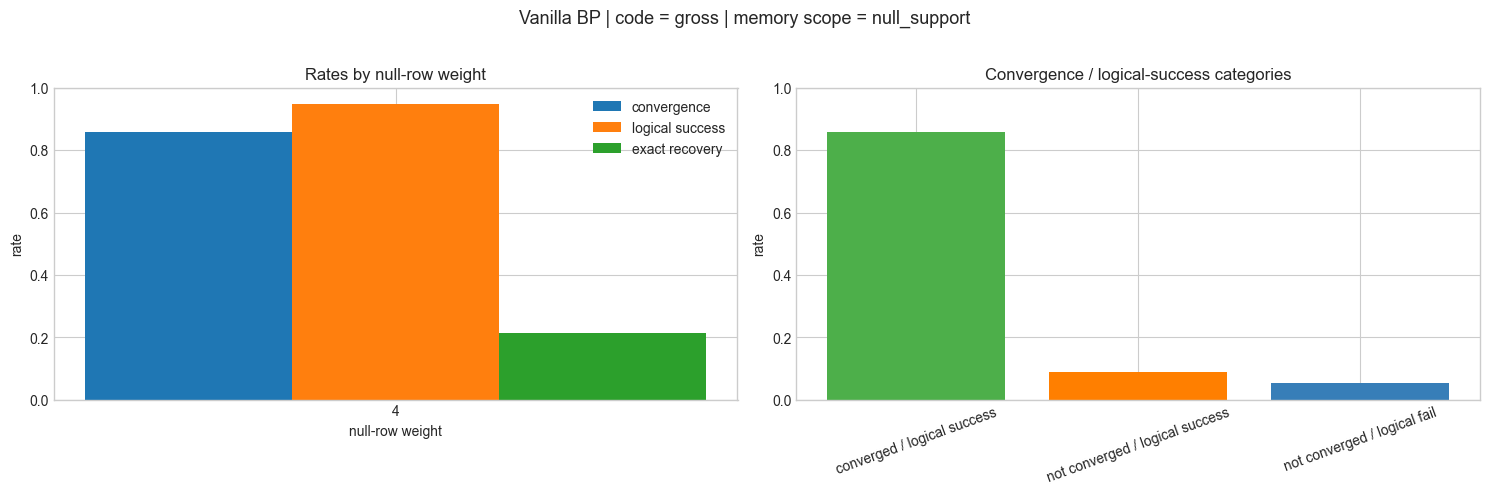

In [5]:
results_bp = evaluate_decoder("bp", all_cases, hz_check_matrix, lz_matrix)
overall_bp = summarize_results(results_bp, len(all_cases))
by_weight_bp = summarize_by_row_weight(results_bp)
categories_bp = category_table(results_bp)
display(overall_bp)
display(by_weight_bp)
display(categories_bp)
plot_decoder_results(results_bp);
plt.show()

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Mem-BP / same coefficient,1536,1,1536,0.942708,0.989583,0.273438,1.0,7.815104,0.057292


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,1536,1536,0.942708,0.989583,0.273438,7.815104


,category,count,rate
0,converged / logical success,1448,0.942708
1,not converged / logical success,72,0.046875
2,not converged / logical fail,16,0.010417


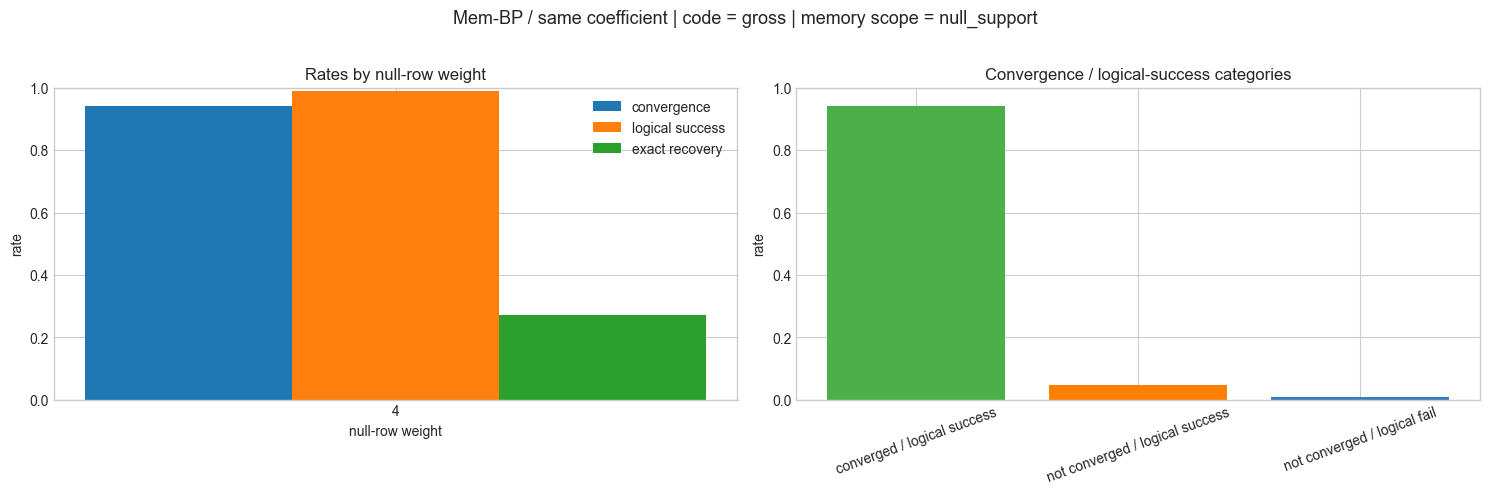

In [6]:
results_mem_same = evaluate_decoder("mem_same", all_cases, hz_check_matrix, lz_matrix)
overall_mem_same = summarize_results(results_mem_same, len(all_cases))
by_weight_mem_same = summarize_by_row_weight(results_mem_same)
categories_mem_same = category_table(results_mem_same)
display(overall_mem_same)
display(by_weight_mem_same)
display(categories_mem_same)
plot_decoder_results(results_mem_same);
plt.show()

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Mem-BP / random positive disorder,1536,3,4608,0.999132,0.999783,0.319878,1.0,1.890842,0.001302


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,4608,1536,0.999132,0.999783,0.319878,1.890842


,category,count,rate
0,converged / logical success,4604,0.999132
1,not converged / logical success,3,0.000651
2,not converged / logical fail,1,0.000217


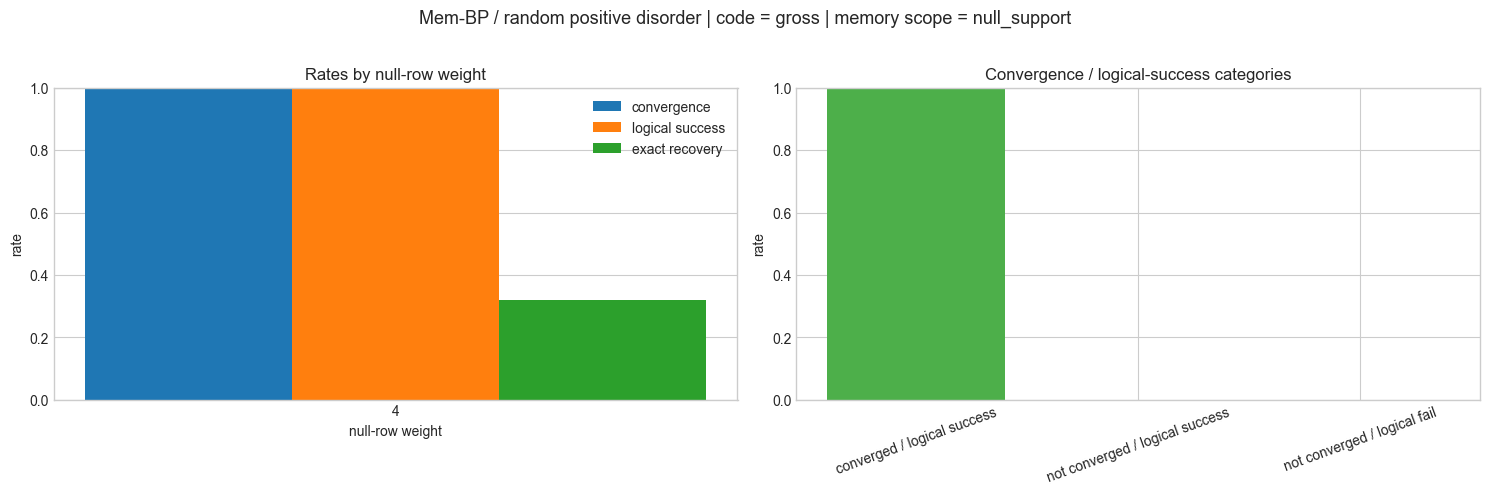

In [7]:
results_mem_positive_random = evaluate_decoder("mem_positive_random", all_cases, hz_check_matrix, lz_matrix)
overall_mem_positive_random = summarize_results(results_mem_positive_random, len(all_cases))
by_weight_mem_positive_random = summarize_by_row_weight(results_mem_positive_random)
categories_mem_positive_random = category_table(results_mem_positive_random)
display(overall_mem_positive_random)
display(by_weight_mem_positive_random)
display(categories_mem_positive_random)
plot_decoder_results(results_mem_positive_random);
plt.show()

,decoder,half_flip_patterns,coefficient_repeats,evaluations,convergence_rate,logical_success_rate,exact_recovery_rate,logical_success_given_converged,mean_iterations,max_iterations_reached_rate
0,Mem-BP / random signed disorder,1536,3,4608,0.990668,0.996094,0.292535,1.0,2.695964,0.0102


,row_weight,evaluations,half_flip_patterns,convergence_rate,logical_success_rate,exact_recovery_rate,mean_iterations
0,4,4608,1536,0.990668,0.996094,0.292535,2.695964


,category,count,rate
0,converged / logical success,4565,0.990668
1,not converged / logical success,25,0.005425
2,not converged / logical fail,18,0.003906


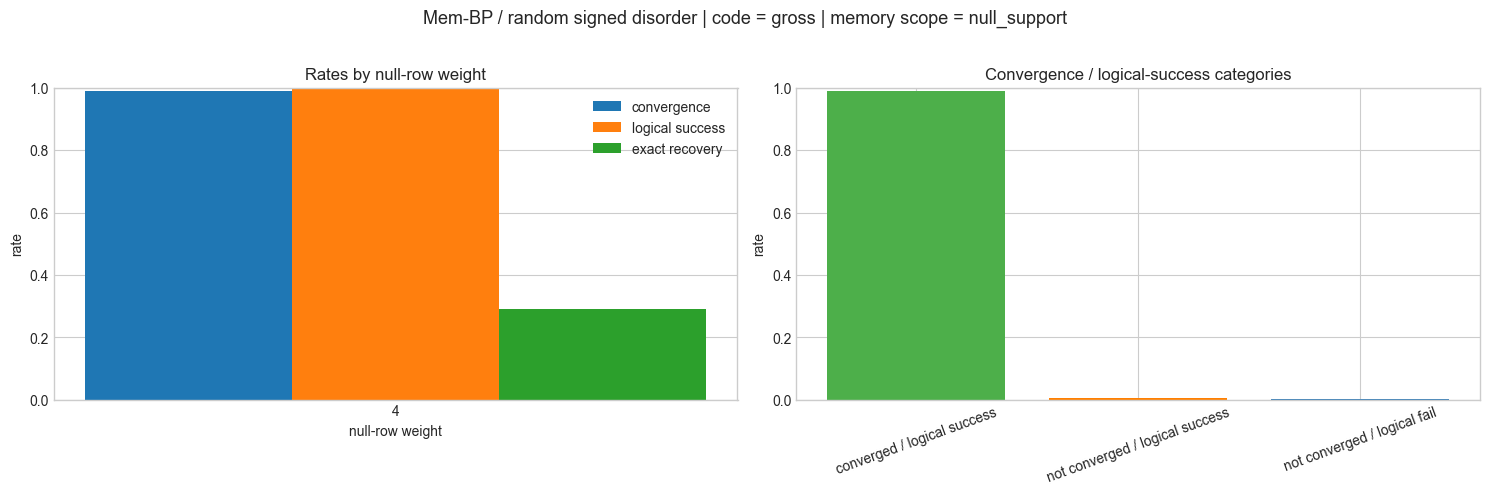

In [8]:
results_mem_signed_random = evaluate_decoder("mem_signed_random", all_cases, hz_check_matrix, lz_matrix)
overall_mem_signed_random = summarize_results(results_mem_signed_random, len(all_cases))
by_weight_mem_signed_random = summarize_by_row_weight(results_mem_signed_random)
categories_mem_signed_random = category_table(results_mem_signed_random)
display(overall_mem_signed_random)
display(by_weight_mem_signed_random)
display(categories_mem_signed_random)
plot_decoder_results(results_mem_signed_random);
plt.show()